# Spatial Correctness and Joint Weather vs Bird Richness

This notebook analyzes bird richness with weather variables jointly (not isolated one-by-one): temp_mean, rainfall, wind_mean, humid_mean, shortwave_radiation.

Scope:
- Spatial thinning: one record per (district, 5 km cell, species)
- Cell-level bird richness
- Joint multivariate weather-richness model
- District-level weather profile and richness patterns


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42


## 1. Load bird + weather columns

In [2]:
candidate_paths = [
    Path("file6.csv"),
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("final5.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find file6.csv or final5.csv from this notebook location.")

weather_cols = [
    "temp_mean",
    "rainfall",
    "wind_mean",
    "humid_mean",
    "shortwave_radiation",
]

raw = pd.read_csv(data_path, low_memory=False)
required_cols = [
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
] + weather_cols

missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw[required_cols].copy()
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
for c in ["decimalLatitude", "decimalLongitude"] + weather_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()

df = df.dropna(subset=[
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
] + weather_cols)

print(f"Using: {data_path.resolve()}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Districts: {df['stateProvince'].nunique():,}")
print(f"Species: {df['verbatimScientificName'].nunique():,}")


Using: D:\maneesha\sem04\intro_DS\project\0020473-260226173443078\file6.csv
Rows after cleaning: 1,552,048
Districts: 25
Species: 429


## 2. Spatial thinning (district, 5 km cell, species)

In [3]:
def add_5km_grid(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    lon0 = float(out["decimalLongitude"].median())
    lat0 = float(out["decimalLatitude"].median())
    lat_rad = np.radians(out["decimalLatitude"].to_numpy())
    out["x_km"] = (out["decimalLongitude"].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
    out["y_km"] = (out["decimalLatitude"].to_numpy() - lat0) * 110.574
    out["grid_x"] = np.floor(out["x_km"] / 5.0).astype(int)
    out["grid_y"] = np.floor(out["y_km"] / 5.0).astype(int)
    out["cell_id"] = (
        out["stateProvince"].astype(str)
        + "|"
        + out["grid_x"].astype(str)
        + "_"
        + out["grid_y"].astype(str)
    )
    return out

def thin_per_species_cell(frame: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    work = frame.copy()
    work["_thin_key"] = (
        work["stateProvince"].astype(str)
        + "|"
        + work["grid_x"].astype(str)
        + "_"
        + work["grid_y"].astype(str)
        + "|"
        + work["verbatimScientificName"].astype(str)
    )
    work["_rand"] = rng.random(len(work))
    return (
        work.sort_values("_rand")
        .groupby("_thin_key", as_index=False)
        .head(1)
        .drop(columns=["_thin_key", "_rand"])
    )

df_grid = add_5km_grid(df)
df_thin = thin_per_species_cell(df_grid, seed=RANDOM_SEED)

print(f"Records before thinning: {len(df_grid):,}")
print(f"Records after thinning:  {len(df_thin):,}")
print(f"Retained fraction:       {len(df_thin)/len(df_grid):.2%}")


Records before thinning: 1,552,048
Records after thinning:  95,608
Retained fraction:       6.16%


## 3. Cell-level richness + joint weather table

In [4]:
agg_dict = {"verbatimScientificName": "nunique"}
for c in weather_cols:
    agg_dict[c] = "mean"

cell_summary = (
    df_thin.groupby(["stateProvince", "cell_id"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"verbatimScientificName": "species_richness"})
)

cell_summary = cell_summary.dropna(subset=["species_richness"] + weather_cols)

print(f"Cell rows for joint weather analysis: {len(cell_summary):,}")
cell_summary.head(10)


Cell rows for joint weather analysis: 1,740


,stateProvince,cell_id,species_richness,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation
0,Ampara,Ampara|14_13,19,28.670000,3.080000,1.830000,73.990000,21.500000
1,Ampara,Ampara|14_17,13,27.436154,1.266154,3.035385,80.355385,23.732308
2,Ampara,Ampara|15_15,47,27.782553,6.318723,2.479574,80.517872,16.897660
3,Ampara,Ampara|17_16,96,27.285312,1.812083,3.984583,76.433125,19.589792
4,Ampara,Ampara|17_17,1,24.780000,6.030000,3.030000,91.220000,10.680000
5,Ampara,Ampara|18_11,4,24.540000,5.680000,1.260000,89.120000,11.590000
6,Ampara,Ampara|19_12,5,27.790000,0.550000,3.660000,70.940000,20.330000
7,Ampara,Ampara|20_10,5,28.980000,0.060000,1.610000,60.830000,25.750000
8,Ampara,Ampara|20_14,26,28.537692,2.351923,1.216923,76.784231,18.618462
9,Ampara,Ampara|21_13,35,27.973429,3.697714,1.583143,79.496857,20.118571


## 4. Joint multivariate model: richness ~ all weather variables

In [5]:
model_df = cell_summary.copy()

for c in weather_cols:
    mu = model_df[c].mean()
    sd = model_df[c].std(ddof=0)
    model_df[f"z_{c}"] = (model_df[c] - mu) / (sd if sd > 0 else 1.0)

z_cols = [f"z_{c}" for c in weather_cols]
formula = "species_richness ~ " + " + ".join(z_cols)
fit = smf.ols(formula, data=model_df).fit()

print(fit.summary().tables[0])
print(fit.summary().tables[1])

rho, pval = stats.spearmanr(model_df["species_richness"], fit.fittedvalues)
print(f"Spearman(observed richness, fitted richness): r={rho:.3f}, p={pval:.3g}")


                            OLS Regression Results                            
Dep. Variable:       species_richness   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.645
Date:                Wed, 08 Apr 2026   Prob (F-statistic):             0.0217
Time:                        21:03:06   Log-Likelihood:                -9158.8
No. Observations:                1740   AIC:                         1.833e+04
Df Residuals:                    1734   BIC:                         1.836e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                54.94

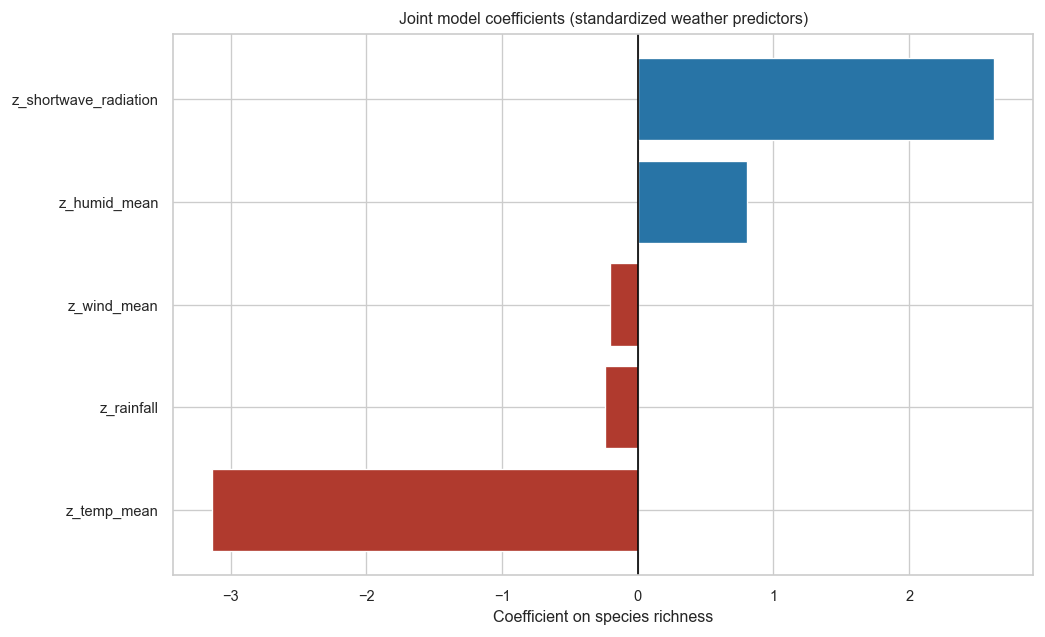

,term,coef,p_value
1,z_temp_mean,-3.136884,0.054689
2,z_rainfall,-0.239956,0.862556
3,z_wind_mean,-0.203915,0.874524
4,z_humid_mean,0.808235,0.636556
5,z_shortwave_radiation,2.627129,0.077018


In [6]:
coef_table = (
    fit.params.rename("coef").to_frame()
    .join(fit.pvalues.rename("p_value"))
    .reset_index()
    .rename(columns={"index": "term"})
)
coef_plot = coef_table[coef_table["term"].str.startswith("z_")].copy()
coef_plot = coef_plot.sort_values("coef")

plt.figure(figsize=(8.8, 5.4))
colors = ["#b03a2e" if x < 0 else "#2874a6" for x in coef_plot["coef"]]
plt.barh(coef_plot["term"], coef_plot["coef"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Joint model coefficients (standardized weather predictors)")
plt.xlabel("Coefficient on species richness")
plt.tight_layout()
plt.show()

coef_plot


## 5. Joint weather-richness structure visualizations

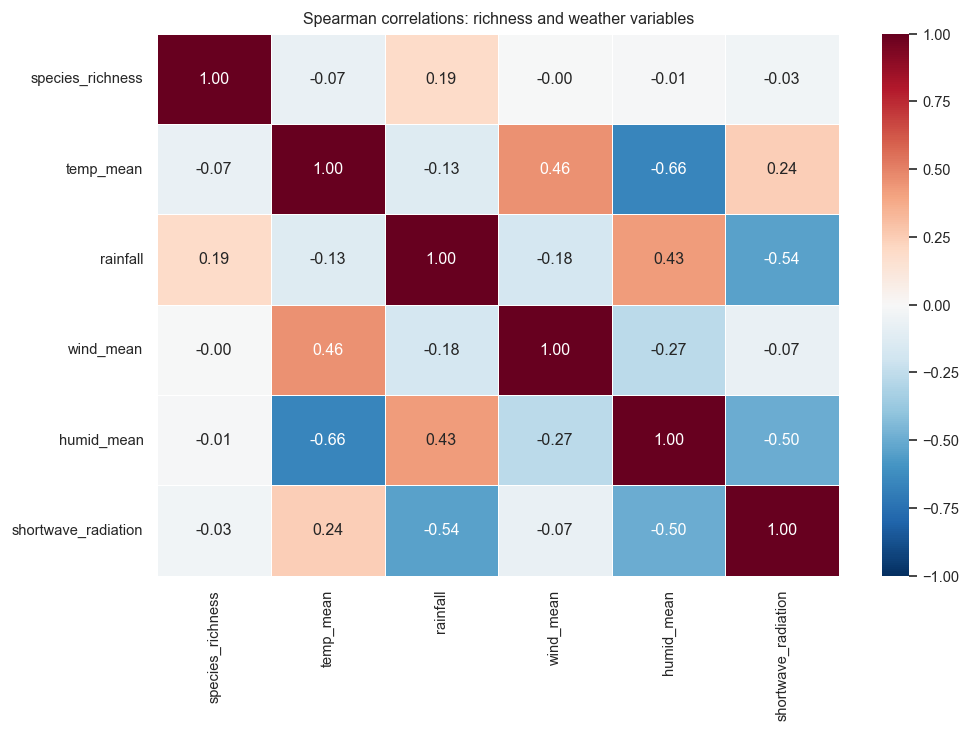

In [7]:
corr_df = cell_summary[["species_richness"] + weather_cols].corr(method="spearman")

plt.figure(figsize=(8.6, 6.2))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.4)
plt.title("Spearman correlations: richness and weather variables")
plt.tight_layout()
plt.show()


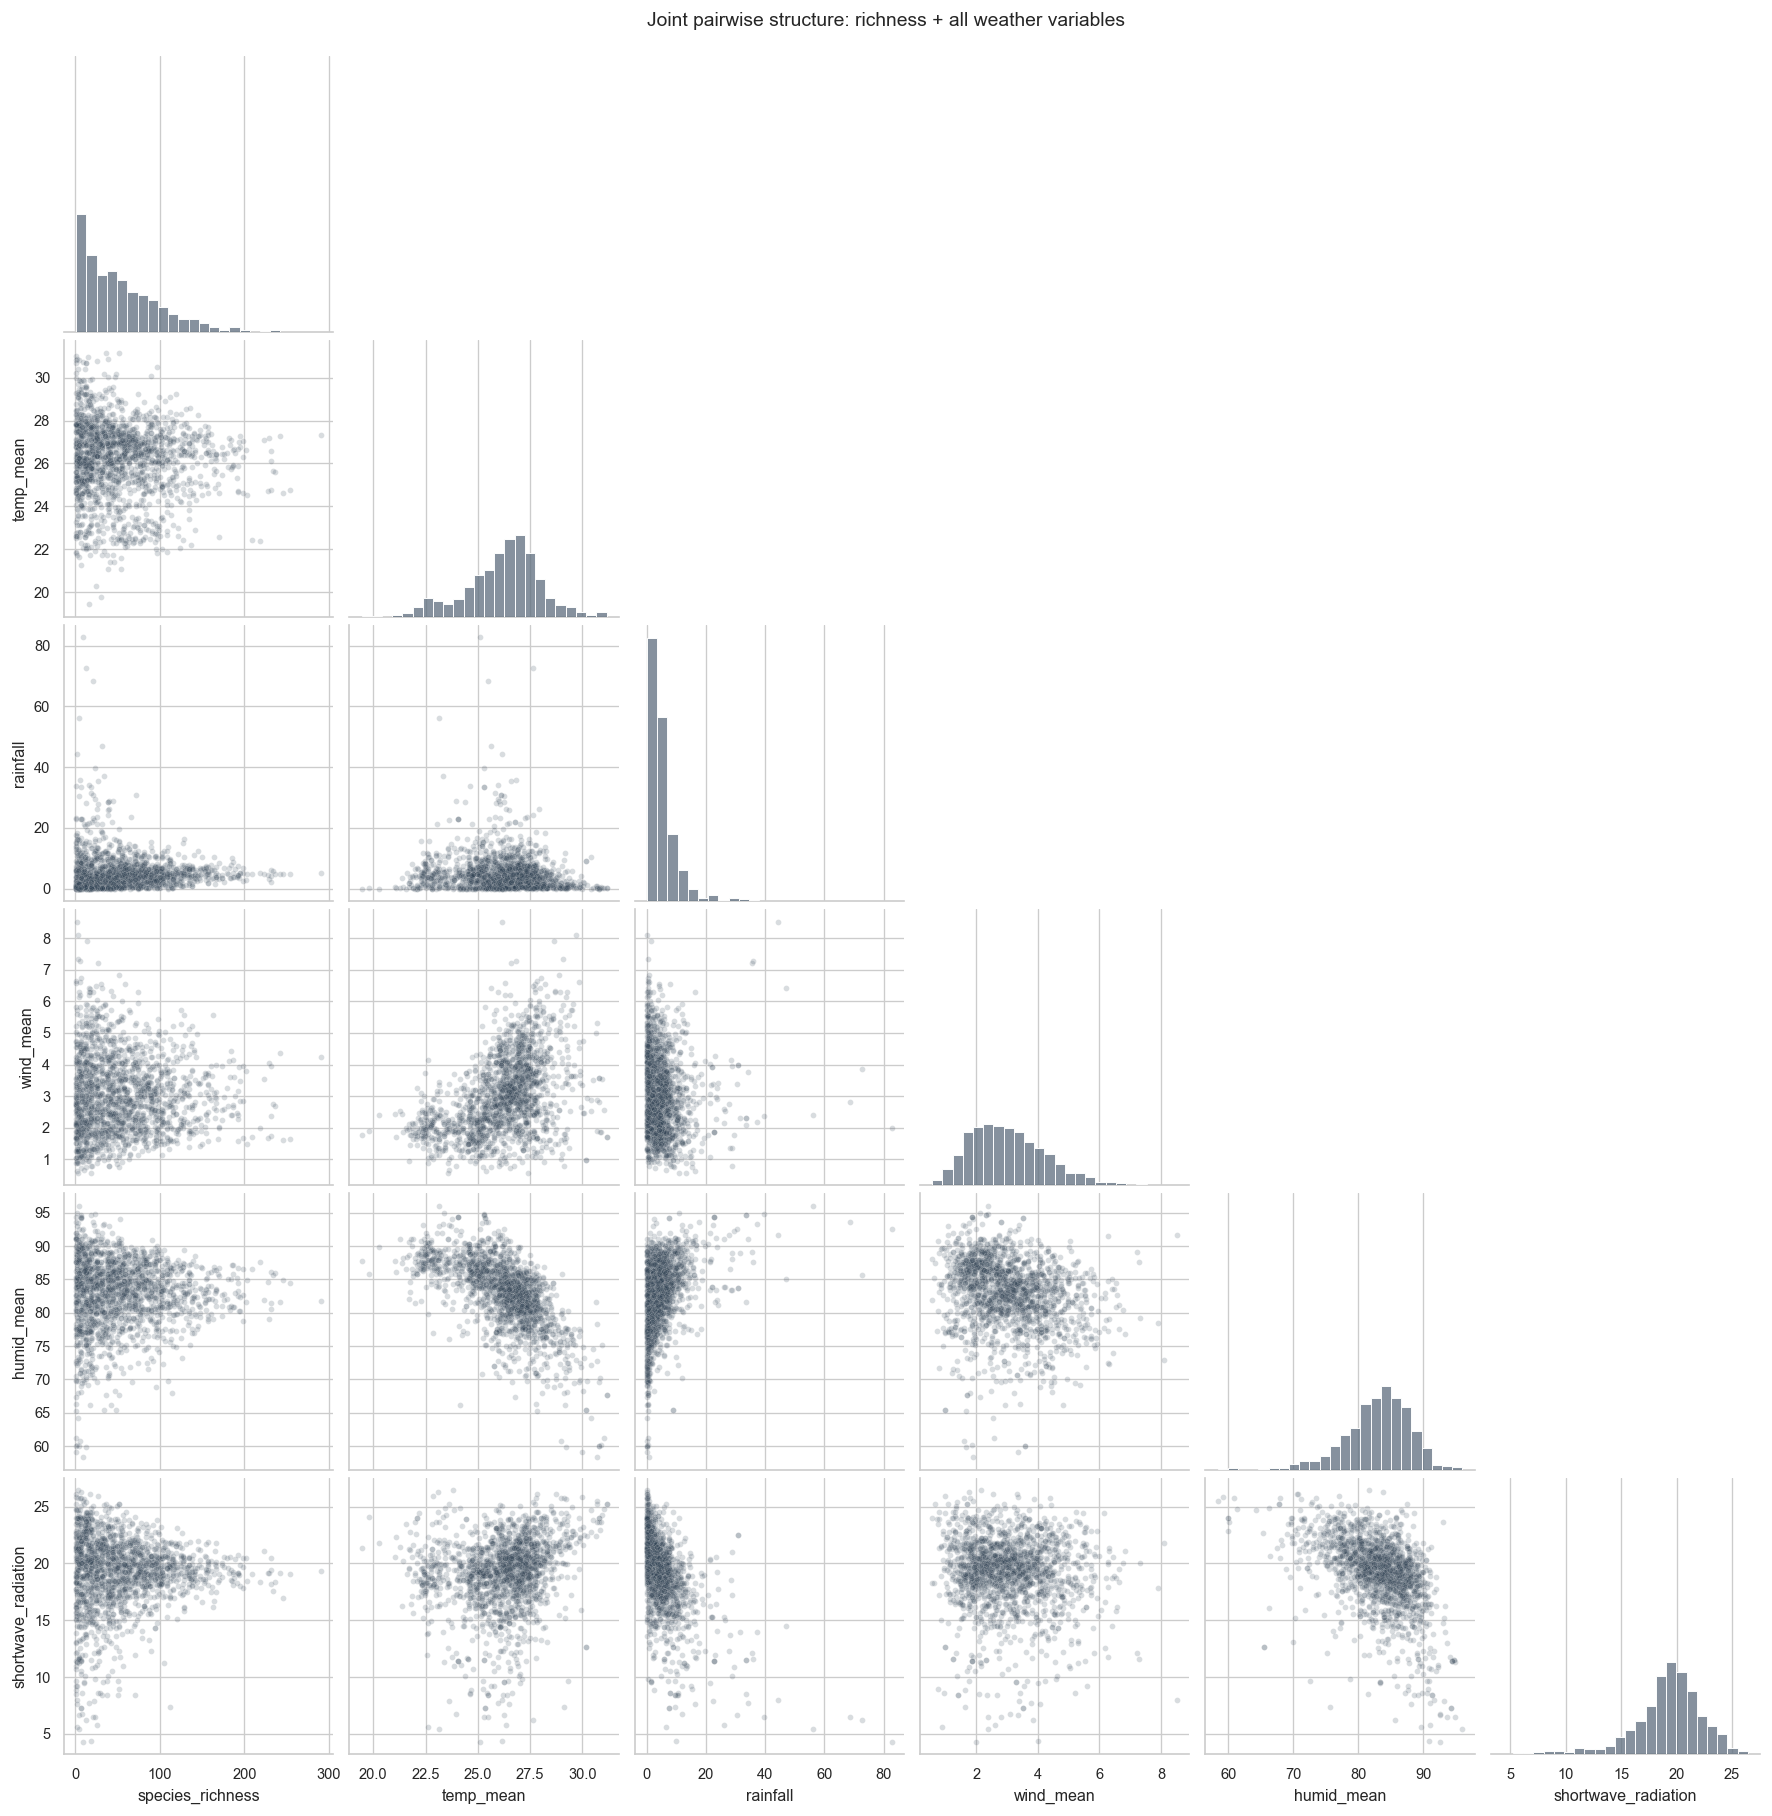

In [8]:
pair_cols = ["species_richness"] + weather_cols
sample_n = min(3500, len(cell_summary))
pair_data = cell_summary[pair_cols].sample(sample_n, random_state=RANDOM_SEED)

g = sns.pairplot(
    pair_data,
    vars=pair_cols,
    corner=True,
    plot_kws={"alpha": 0.18, "s": 12, "color": "#2c3e50"},
    diag_kws={"bins": 24, "color": "#5d6d7e"},
)
g.fig.suptitle("Joint pairwise structure: richness + all weather variables", y=1.01)
plt.show()


## 6. District-level joint weather profile

,stateProvince,mean_cell_richness,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation,n_cells,z_temp_mean,z_rainfall,z_wind_mean,z_humid_mean,z_shortwave_radiation
4,Colombo,84.769231,26.543466,6.199336,3.077753,82.648337,19.517801,39,0.129791,1.120764,-0.081803,0.135022,0.334914
7,Hambantota,80.955056,26.700718,5.292769,3.528069,83.758490,18.941468,89,0.251565,0.320415,0.525619,0.515576,-0.402399
14,Mannar,80.740000,27.129575,3.485328,3.867924,79.715430,19.048886,50,0.583665,-1.275256,0.984044,-0.870361,-0.264978
6,Gampaha,69.720588,26.666600,5.321435,3.166151,83.079850,19.508377,68,0.225144,0.345723,0.037435,0.282942,0.322858
16,Matara,68.947368,26.760254,5.422278,3.108697,83.593280,18.741656,57,0.297668,0.434751,-0.040064,0.458943,-0.658022
15,Matale,64.485294,25.575096,4.210645,2.603344,83.373161,19.231059,68,-0.620101,-0.634921,-0.721724,0.383487,-0.031920
17,Monaragala,59.850000,25.433780,6.250122,2.486940,84.674025,19.109013,100,-0.729534,1.165600,-0.878739,0.829416,-0.188056
21,Puttalam,59.247525,26.953685,4.595843,3.807001,81.256321,20.074057,101,0.447458,-0.294855,0.901865,-0.342153,1.046542
10,Kandy,58.507042,24.265342,5.341957,2.190736,85.172572,19.216471,71,-1.634356,0.363840,-1.278283,1.000315,-0.050583
8,Jaffna,57.818182,27.605017,3.483783,4.653740,77.176239,19.864505,55,0.951840,-1.276621,2.044015,-1.740781,0.778459


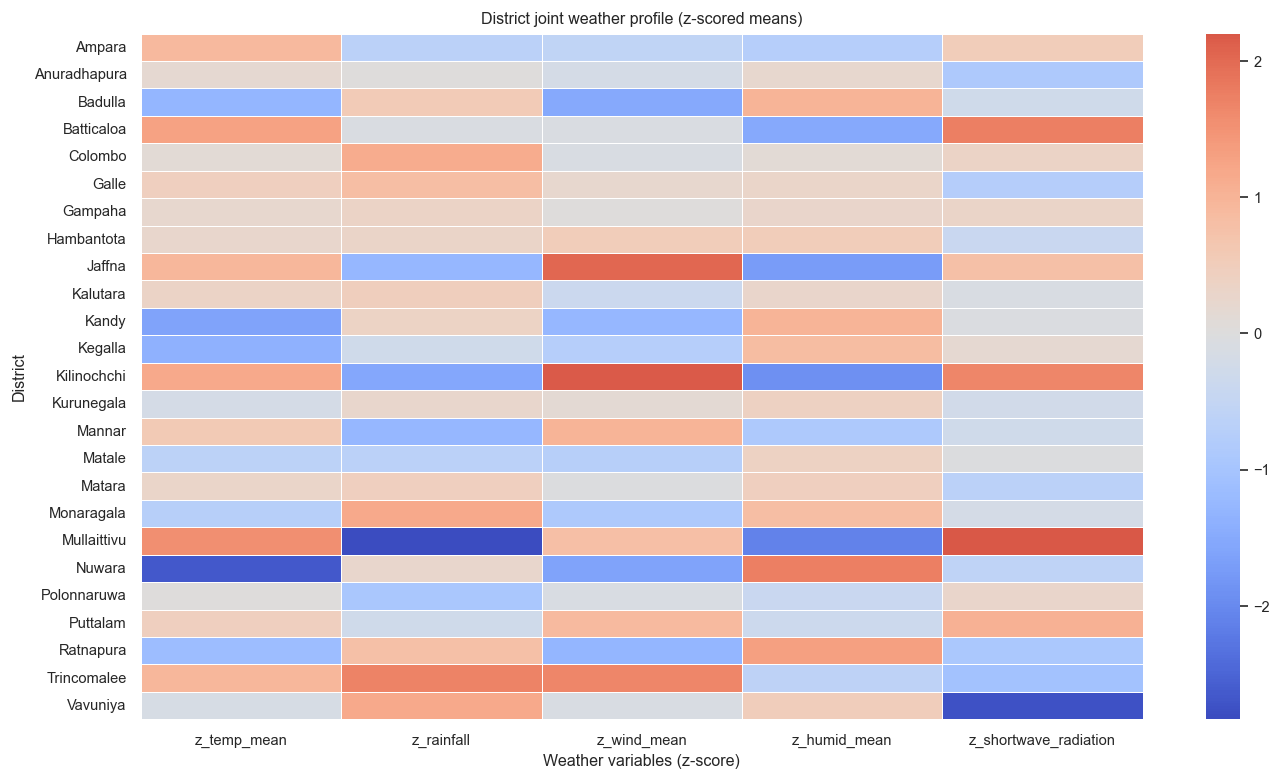

In [9]:
district_joint = (
    cell_summary.groupby("stateProvince", as_index=False)
    .agg({"species_richness": "mean", **{c: "mean" for c in weather_cols}, "cell_id": "count"})
    .rename(columns={"species_richness": "mean_cell_richness", "cell_id": "n_cells"})
)

for c in weather_cols:
    district_joint[f"z_{c}"] = (district_joint[c] - district_joint[c].mean()) / district_joint[c].std(ddof=0)

z_weather_cols = [f"z_{c}" for c in weather_cols]
profile = district_joint[["stateProvince"] + z_weather_cols].set_index("stateProvince")

display(district_joint.sort_values("mean_cell_richness", ascending=False).head(30))

plt.figure(figsize=(11.8, 6.6))
sns.heatmap(profile, cmap="coolwarm", center=0, linewidths=0.4)
plt.title("District joint weather profile (z-scored means)")
plt.xlabel("Weather variables (z-score)")
plt.ylabel("District")
plt.tight_layout()
plt.show()


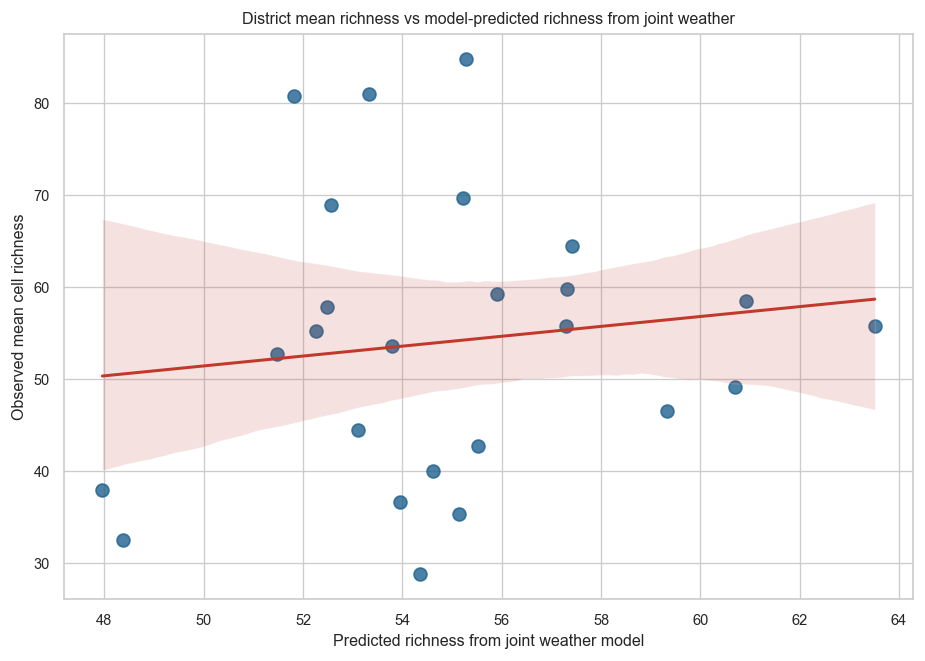

In [10]:
district_joint["pred_richness_from_weather"] = fit.predict(
    district_joint.assign(**{f"z_{c}": district_joint[f"z_{c}"] for c in weather_cols})
)

plt.figure(figsize=(7.8, 5.6))
sns.regplot(
    data=district_joint,
    x="pred_richness_from_weather",
    y="mean_cell_richness",
    scatter_kws={"s": 60, "alpha": 0.8, "color": "#1f618d"},
    line_kws={"color": "#c0392b"},
)
plt.title("District mean richness vs model-predicted richness from joint weather")
plt.xlabel("Predicted richness from joint weather model")
plt.ylabel("Observed mean cell richness")
plt.tight_layout()
plt.show()


## 7. Optional exports

In [11]:
# Uncomment to export outputs.
# cell_summary.to_csv("weather_cell_summary.csv", index=False)
# district_joint.to_csv("weather_district_joint_summary.csv", index=False)
# coef_plot.to_csv("weather_joint_model_coefficients.csv", index=False)
